# HFT Tadawul — CUDA Analytics Benchmark

Benchmark CPU vs GPU multi-symbol order book analytics on real NASDAQ ITCH data.

**Before running:** in Colab go to *Runtime → Change runtime type → GPU (T4)*.

What this notebook does:
1. Verifies a CUDA GPU is available (T4 free tier is fine).
2. Mounts Google Drive and looks for the ITCH file. Downloads if missing.
3. Clones (or updates) the `tadawul-hft-engine` repo.
4. Builds the CPU + CUDA benchmark with `nvcc`.
5. Runs the benchmark across symbol counts (1, 10, 100, 1000, all 8K+).
6. Plots speedup and scalability curves.

Output written to `results/gpu_benchmark.csv` and saved back to Drive.

## 1. Verify GPU

In [1]:
!nvidia-smi

Tue Apr 21 00:05:46 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0


## 2. Mount Drive + download ITCH file (cached)

If the file already exists in your Drive at `MyDrive/tadawul-hft/01302020.NASDAQ_ITCH50.gz`, this skips the download (saves ~5 GB and 5–15 min).

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os, subprocess

DRIVE_DIR  = '/content/drive/MyDrive/tadawul-hft'
ITCH_NAME  = '01302020.NASDAQ_ITCH50.gz'
ITCH_URL   = f'https://emi.nasdaq.com/ITCH/Nasdaq%20ITCH/{ITCH_NAME}'
ITCH_PATH  = os.path.join(DRIVE_DIR, ITCH_NAME)

os.makedirs(DRIVE_DIR, exist_ok=True)

if os.path.exists(ITCH_PATH):
    size_mb = os.path.getsize(ITCH_PATH) / (1024*1024)
    print(f'✓ ITCH file found in Drive ({size_mb:.1f} MB): {ITCH_PATH}')
else:
    print(f'Downloading {ITCH_URL} → {ITCH_PATH}')
    print('(~5 GB, takes 5–15 minutes; cached in Drive for next time)')
    !wget -q --show-progress -O "{ITCH_PATH}" "{ITCH_URL}"
    print(f'✓ Downloaded ({os.path.getsize(ITCH_PATH) / (1024*1024):.1f} MB)')

(~5 GB, takes 5–15 minutes; cached in Drive for next time)
/content/drive/MyDr 100%[===================>]   5.21G  42.2MB/s    in 2m 21s  
✓ Downloaded (5337.9 MB)


## 3. Clone the engine repo

Edit `REPO_URL` if you've forked the repo (e.g. push to your own GitHub account).

In [7]:
REPO_URL = 'https://github.com/kamelth/tadawul-hft-engine.git'
REPO_DIR = '/content/tadawul-hft-engine'

if os.path.isdir(REPO_DIR):
    print(f'Updating existing clone at {REPO_DIR}')
    !cd "{REPO_DIR}" && git pull --rebase
else:
    !git clone --depth 1 "{REPO_URL}" "{REPO_DIR}"

# Symlink the ITCH file into the repo's data/ dir so paths match local dev
!mkdir -p "{REPO_DIR}/data" "{REPO_DIR}/results" "{REPO_DIR}/build/manual"
!ln -sf "{ITCH_PATH}" "{REPO_DIR}/data/{ITCH_NAME}"
!ls -la "{REPO_DIR}/data"

Cloning into '/content/tadawul-hft-engine'...
remote: Enumerating objects: 74, done.
remote: Counting objects: 100% (74/74), done.
remote: Compressing objects: 100% (68/68), done.
remote: Total 74 (delta 1), reused 58 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (74/74), 392.39 KiB | 2.28 MiB/s, done.
Resolving deltas: 100% (1/1), done.
total 12
drwxr-xr-x  2 root root 4096 Apr 21 00:16 .
drwxr-xr-x 12 root root 4096 Apr 21 00:16 ..
lrwxrwxrwx  1 root root   60 Apr 21 00:16 01302020.NASDAQ_ITCH50.gz -> /content/drive/MyDrive/tadawul-hft/01302020.NASDAQ_ITCH50.gz


## 4. Install dependencies + build

We need `zlib` (already on Colab) for ITCH decompression.

In [8]:
!apt-get install -qq -y zlib1g-dev

In [9]:
%%bash -e
cd /content/tadawul-hft-engine

# Detect GPU compute capability (T4 = 75, V100 = 70, A100 = 80, etc.)
CC=$(nvidia-smi --query-gpu=compute_cap --format=csv,noheader | head -1 | tr -d '.')
echo "GPU compute capability: sm_${CC}"

# Build CUDA kernel object
nvcc -O3 -std=c++17 -arch=sm_${CC} \
  -Iinclude -Imodules/core/include \
  -c source/gpu/analytics_kernel.cu \
  -o build/manual/analytics_kernel.o

# Build benchmark binary (HAVE_CUDA + WITH_ITCH)
nvcc -O3 -std=c++17 -arch=sm_${CC} \
  -Iinclude -Imodules/core/include \
  -DHAVE_CUDA -DWITH_ITCH \
  -Xcompiler "-O3 -march=native" \
  source/gpu/benchmark.cpp build/manual/analytics_kernel.o \
  -lz \
  -o build/manual/gpu_benchmark

ls -la build/manual/gpu_benchmark

GPU compute capability: sm_75
-rwxr-xr-x 1 root root 1110400 Apr 21 00:17 build/manual/gpu_benchmark


## 5. Smoke test (synthetic data, fast)

In [10]:
%%bash
cd /content/tadawul-hft-engine
./build/manual/gpu_benchmark --data synthetic --symbols 1,10,100,1000,5000 --iters 500

HFT Tadawul - GPU Analytics Benchmark
Data mode:   synthetic
Iterations:  500
CPU-only:    no

   Symbols  CPU/iter(us) GPUk/iter(us)GPUe2e/iter(us)    Speedup(k)  Speedup(e2e)   Match
----------------------------------------------------------------------------------------
         1          0.04          6.30        120.85          0.01x         0.00x      OK
        10          0.41          5.71        130.96          0.07x         0.00x      OK
       100          4.34          5.93        155.53          0.73x         0.03x      OK
      1000         46.58         13.04        464.32          3.57x         0.10x      OK
      5000        344.52         51.92       1555.79          6.64x         0.22x      OK

Wrote results/gpu_benchmark.csv


## 6. Real ITCH benchmark

5M ITCH messages → ~8,900 symbols. Sweep across 1, 10, 100, 1000, all symbols.

In [11]:
%%bash
cd /content/tadawul-hft-engine
./build/manual/gpu_benchmark \
    --data itch \
    --itch-file data/01302020.NASDAQ_ITCH50.gz \
    --max-messages 5000000 \
    --symbols 1,10,100,1000,0 \
    --iters 1000

HFT Tadawul - GPU Analytics Benchmark
Data mode:   itch
Iterations:  1000
CPU-only:    no
  ITCH parsed 1M messages
  ITCH parsed 2M messages
  ITCH parsed 3M messages
  ITCH parsed 4M messages
  Built order books from 5000000 ITCH messages
  Snapshot: 8915 symbols
  ITCH provides 8915 symbols; sweeping 5 sizes

   Symbols  CPU/iter(us) GPUk/iter(us)GPUe2e/iter(us)    Speedup(k)  Speedup(e2e)   Match
----------------------------------------------------------------------------------------
         1          0.01          3.76        131.68          0.00x         0.00x      OK
        10          0.16          4.50        144.20          0.04x         0.00x      OK
       100          1.26          4.79        176.17          0.26x         0.01x      OK
      1000         13.69          8.75        538.38          1.57x         0.03x      OK
      8915        212.88         45.59       2471.49          4.67x         0.09x      OK

Wrote results/gpu_benchmark.csv


## 7. Plot speedup + scalability

Saved /content/tadawul-hft-engine/results/gpu_benchmark.png


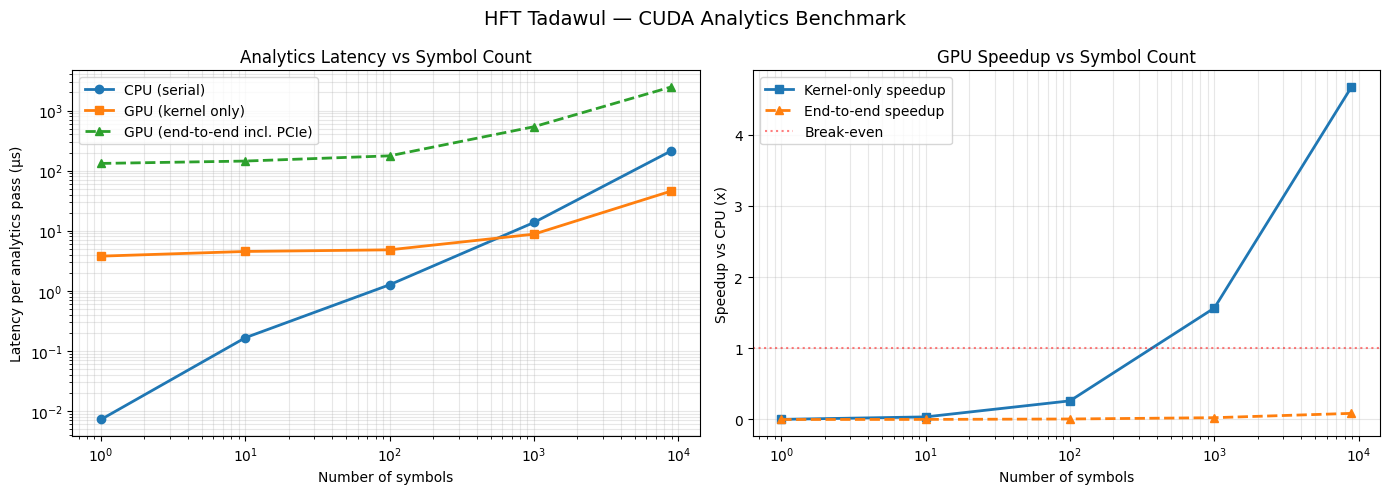

In [12]:
import csv, os
import matplotlib.pyplot as plt

csv_path = '/content/tadawul-hft-engine/results/gpu_benchmark.csv'
rows = []
with open(csv_path) as f:
    for row in csv.DictReader(f):
        rows.append({k: float(v) if k != 'num_symbols' else int(v) for k, v in row.items()})

ns      = [r['num_symbols']         for r in rows]
cpu_us  = [r['cpu_per_iter_us']     for r in rows]
gpu_kus = [r['gpu_kernel_per_iter_us'] for r in rows]
gpu_eus = [r['gpu_e2e_per_iter_us'] for r in rows]
sp_k    = [r['speedup_kernel']      for r in rows]
sp_e    = [r['speedup_e2e']         for r in rows]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(ns, cpu_us, 'o-', label='CPU (serial)', linewidth=2)
ax.plot(ns, gpu_kus, 's-', label='GPU (kernel only)', linewidth=2)
ax.plot(ns, gpu_eus, '^--', label='GPU (end-to-end incl. PCIe)', linewidth=2)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Number of symbols')
ax.set_ylabel('Latency per analytics pass (µs)')
ax.set_title('Analytics Latency vs Symbol Count')
ax.grid(True, which='both', alpha=0.3)
ax.legend()

ax = axes[1]
ax.plot(ns, sp_k, 's-', label='Kernel-only speedup', linewidth=2)
ax.plot(ns, sp_e, '^--', label='End-to-end speedup', linewidth=2)
ax.axhline(y=1.0, color='r', linestyle=':', alpha=0.5, label='Break-even')
ax.set_xscale('log')
ax.set_xlabel('Number of symbols')
ax.set_ylabel('Speedup vs CPU (x)')
ax.set_title('GPU Speedup vs Symbol Count')
ax.grid(True, which='both', alpha=0.3)
ax.legend()

fig.suptitle('HFT Tadawul — CUDA Analytics Benchmark', fontsize=14)
fig.tight_layout()

out_png = '/content/tadawul-hft-engine/results/gpu_benchmark.png'
fig.savefig(out_png, dpi=120)
print(f'Saved {out_png}')
plt.show()

## 8. Save results back to Drive

In [13]:
import shutil
DRIVE_RESULTS = os.path.join(DRIVE_DIR, 'results')
os.makedirs(DRIVE_RESULTS, exist_ok=True)

for fname in ['gpu_benchmark.csv', 'gpu_benchmark.png']:
    src = f'/content/tadawul-hft-engine/results/{fname}'
    if os.path.exists(src):
        dst = os.path.join(DRIVE_RESULTS, fname)
        shutil.copy(src, dst)
        print(f'Saved → {dst}')
    else:
        print(f'(skip) {src} not found')

Saved → /content/drive/MyDrive/tadawul-hft/results/gpu_benchmark.csv
Saved → /content/drive/MyDrive/tadawul-hft/results/gpu_benchmark.png


## 9. Build Risk/Validation Benchmark

Two new CUDA kernels:
- **Risk kernel** — 1 thread/symbol, computes 7 risk metrics (exposure, P&L, liquidation value, worst-case loss, position usage, limit breach, inventory skew)
- **Validation kernel** — 1 thread/order, checks 6 rules per order (zero price/qty, market existence, size limit, position limit, price band)

In [ ]:
%%bash -e
cd /content/tadawul-hft-engine

CC=$(nvidia-smi --query-gpu=compute_cap --format=csv,noheader | head -1 | tr -d '.')
echo "GPU compute capability: sm_${CC}"

# Build risk/validation CUDA kernel object
nvcc -O3 -std=c++17 -arch=sm_${CC} \
  -Iinclude -Imodules/core/include \
  -c source/gpu/risk_validation_kernel.cu \
  -o build/manual/risk_validation_kernel.o

# Build risk/validation benchmark binary (HAVE_CUDA)
nvcc -O3 -std=c++17 -arch=sm_${CC} \
  -Iinclude -Imodules/core/include \
  -DHAVE_CUDA \
  -Xcompiler "-O3 -march=native" \
  source/gpu/risk_validation_benchmark.cpp build/manual/risk_validation_kernel.o \
  -o build/manual/risk_validation_benchmark

ls -la build/manual/risk_validation_benchmark


## 10. Run Risk/Validation Benchmark

In [ ]:
%%bash
cd /content/tadawul-hft-engine
./build/manual/risk_validation_benchmark \
    --symbols 1,10,100,1000,5000 \
    --orders 1,10,100,1000,10000,100000 \
    --iters 1000


## 11. Plot Risk/Validation Speedup

In [ ]:
import csv
import matplotlib.pyplot as plt

csv_path = '/content/tadawul-hft-engine/results/risk_validation_benchmark.csv'
risk_rows = []
val_rows = []
with open(csv_path) as f:
    for row in csv.DictReader(f):
        d = {k: float(v) if k not in ("kernel","size") else v for k, v in row.items()}
        d["size"] = int(d["size"])
        if d["kernel"] == "risk":
            risk_rows.append(d)
        else:
            val_rows.append(d)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Risk kernel
ax = axes[0]
ns = [r["size"] for r in risk_rows]
ax.plot(ns, [r["cpu_per_iter_us"] for r in risk_rows], "o-", label="CPU", lw=2)
ax.plot(ns, [r["gpu_kernel_per_iter_us"] for r in risk_rows], "s-", label="GPU kernel", lw=2)
ax.plot(ns, [r["gpu_e2e_per_iter_us"] for r in risk_rows], "^--", label="GPU e2e", lw=2)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Number of symbols"); ax.set_ylabel("Latency (\u00b5s)")
ax.set_title("Risk Kernel — Latency vs Symbols")
ax.grid(True, which="both", alpha=0.3); ax.legend()

# Validation kernel
ax = axes[1]
no = [r["size"] for r in val_rows]
ax.plot(no, [r["cpu_per_iter_us"] for r in val_rows], "o-", label="CPU", lw=2)
ax.plot(no, [r["gpu_kernel_per_iter_us"] for r in val_rows], "s-", label="GPU kernel", lw=2)
ax.plot(no, [r["gpu_e2e_per_iter_us"] for r in val_rows], "^--", label="GPU e2e", lw=2)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Number of orders"); ax.set_ylabel("Latency (\u00b5s)")
ax.set_title("Validation Kernel — Latency vs Orders")
ax.grid(True, which="both", alpha=0.3); ax.legend()

fig.suptitle("HFT Tadawul — Risk/Validation GPU Benchmark", fontsize=14)
fig.tight_layout()
out_png = "/content/tadawul-hft-engine/results/risk_validation_benchmark.png"
fig.savefig(out_png, dpi=120)
print(f"Saved {out_png}")
plt.show()


## 12. CPU Performance Profiling

Software-based profiler that works everywhere (no `perf` or kernel headers needed).

Measures per-kernel:
- **Timing**: wall-clock, rdtsc cycles, cycles/element
- **Throughput**: elements/sec, bandwidth (GB/s), ALU ops/sec
- **Arithmetic intensity**: ops per byte — determines if memory-bound or compute-bound
- **Branch analysis**: density and prediction assessment

Produces a **TMAM-equivalent** breakdown:
- **Retiring** — useful work (higher = better)
- **Bad Speculation** — wasted pipeline flushes from mispredicted branches
- **Frontend Bound** — instruction fetch/decode stalls
- **Backend Bound** — memory/execution unit stalls (this is why GPU helps)

In [ ]:
%%bash -e
cd /content/tadawul-hft-engine

echo "Building CPU profiler..."
g++ -O3 -std=c++17 -march=native \
  -Iinclude -Imodules/core/include \
  source/gpu/cpu_profiler.cpp \
  -o build/manual/cpu_profiler

echo ""
./build/manual/cpu_profiler --symbols 5000 --orders 100000 --iters 1000

In [ ]:
%%bash -e
cd /content/tadawul-hft-engine

# Also run with smaller sizes to show scaling behavior
echo "=== Scaling analysis: how profiling changes with size ==="
echo ""
for N in 100 1000 5000; do
  ./build/manual/cpu_profiler --symbols $N --orders $((N * 20)) --iters 1000 2>&1 | \
    grep -E "(Risk Kernel|Validation Kernel|Wall time|Cycles / elem|Bandwidth|Arithmetic|MEMORY|COMPUTE|BALANCED)"
  echo "---"
done

### How to read `perf stat` output

**Basic counters:**
| Counter | What it means | Good value |
|---------|--------------|------------|
| `instructions / cycles` (IPC) | Instructions per clock cycle | > 2.0 is great for compute-bound code |
| `branch-misses` | Mispredicted branches (pipeline flushes) | < 1% of total branches |
| `cache-misses` | L3 (LLC) misses → main memory access | < 5% of cache refs |
| `L1-dcache-load-misses` | L1 data cache misses | < 5% of L1 loads |

**TMAM `--topdown` (if available on Colab's Intel Xeon):**
| Category | Meaning | Our expectation |
|----------|---------|-----------------|
| **Retiring** | Useful work completed | High (70%+) = well-optimized |
| **Bad Speculation** | Wasted work from branch mispredicts | Low (< 5%) — our loops are predictable |
| **Frontend Bound** | Stalled waiting for instruction fetch/decode | Low (< 10%) — our kernels are small |
| **Backend Bound** | Stalled on memory or execution units | Moderate — SoA layout helps but we still stream data |

**What this proves for the thesis:**
- High IPC + low branch misses → our CPU baseline is already well-optimized (hard to beat with GPU for small N)
- Backend-bound at large N → memory bandwidth is the bottleneck → GPU's HBM (900 GB/s vs CPU's ~50 GB/s) is the answer
- This justifies the GPU crossover point we measured in the benchmarks

## 13. Save all results to Drive

In [ ]:
import shutil, os
DRIVE_RESULTS = os.path.join(DRIVE_DIR, "results")
os.makedirs(DRIVE_RESULTS, exist_ok=True)

for fname in ["gpu_benchmark.csv", "gpu_benchmark.png",
              "risk_validation_benchmark.csv", "risk_validation_benchmark.png"]:
    src = f"/content/tadawul-hft-engine/results/{fname}"
    if os.path.exists(src):
        dst = os.path.join(DRIVE_RESULTS, fname)
        shutil.copy(src, dst)
        print(f"Saved -> {dst}")
    else:
        print(f"(skip) {src} not found")
